# Bilbiotecas

In [2]:
import pandas               as pd
import numpy                as np
import matplotlib.pyplot    as plt
import seaborn              as sns
import statsmodels.api      as sm
import math
import joblib
import json

from sklearn.model_selection    import train_test_split
from sklearn.preprocessing      import RobustScaler
from sklearn.linear_model       import LogisticRegression
from sklearn.metrics            import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    recall_score,
    precision_score,
    f1_score,
    accuracy_score,
    ConfusionMatrixDisplay
    )
from scipy.stats import gaussian_kde

# Dataset

In [3]:
dataset = pd.read_csv('dados_brutos\\tarefas_clientes_treino_teste.csv', sep=';')
# Convertendo colunas object com vírgula para float numérico
colunas_para_ajustar = ['perc_prioridade_maxima'] + \
                        list(dataset.filter(regex='score').columns) + \
                        list(dataset.filter(regex='media').columns)

dataset['primeira_assinatura'] = pd.to_datetime(dataset['primeira_assinatura'], errors='raise', format='%d/%m/%Y')

for col in colunas_para_ajustar:
    dataset[col] = dataset[col].astype(str).str.replace(',', '.').astype(float)

dataset.head()

,cod_cliente,primeira_assinatura,flag_ja_sofreu_downgrade,qt_tarefas_total,media_dias_exec,qt_tarefas_sd,media_dias_exec_tarefa_sd,qt_tarefas_hd,media_dias_exec_tarefa_hd,qt_tarefas_reclamacao,...,qt_categorias_distintas,qt_subcategorias_distintas,qt_grupos_envolvidos,qt_prioridade_normal,qt_prioridade_parcial,qt_prioridade_urgente,qt_prioridade_maxima,qt_prioridade_reforco,perc_prioridade_maxima,churn
0,10,2013-05-04,0,4,64.5000,1,26.0000,0,0.0000,0,...,3,2,4,4,0,0,0,0,0.00,1
1,20,2001-03-20,0,718,21.5878,97,16.8557,201,8.1055,0,...,39,90,23,694,4,13,7,0,0.97,0
2,22,2011-03-21,0,77,12.2727,6,2.0000,46,5.4783,0,...,16,27,13,75,0,0,2,0,2.60,1
3,29,2020-10-30,0,19,22.6316,1,12.0000,10,4.7000,0,...,9,11,7,17,1,0,1,0,5.26,0
4,32,2012-02-13,0,157,48.8854,67,33.0896,20,12.2500,0,...,21,29,16,155,1,1,0,0,0.00,1


In [4]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4701 entries, 0 to 4700
Data columns (total 30 columns):
 #   Column                        Non-Null Count  Dtype         
---  ------                        --------------  -----         
 0   cod_cliente                   4701 non-null   int64         
 1   primeira_assinatura           4701 non-null   datetime64[ns]
 2   flag_ja_sofreu_downgrade      4701 non-null   int64         
 3   qt_tarefas_total              4701 non-null   int64         
 4   media_dias_exec               4701 non-null   float64       
 5   qt_tarefas_sd                 4701 non-null   int64         
 6   media_dias_exec_tarefa_sd     4701 non-null   float64       
 7   qt_tarefas_hd                 4701 non-null   int64         
 8   media_dias_exec_tarefa_hd     4701 non-null   float64       
 9   qt_tarefas_reclamacao         4701 non-null   int64         
 10  media_dias_exec_reclamacao    4701 non-null   float64       
 11  qt_tarefas_reducao            

In [5]:
media_dias_ano_bissexto = 30.44

# Por que não usar apenas 30?
# Se você dividir o total de dias por 30 em uma base histórica longa
# (como um cliente que está com você desde 2011, igual ao exemplo do cliente 17029),
# o modelo vai acumular um erro de quase 5 dias por ano. No longo prazo, isso faria o
# cálculo do Tenure (tempo de casa) parecer maior do que a realidade,
# adicionando meses "fantasmas" ao seu dataset.

In [6]:
# Transformando a 'primeira_assinatura' em Feature Numérica
dataset['primeira_assinatura'] = pd.to_datetime(dataset['primeira_assinatura'])
data_referencia = dataset['primeira_assinatura'].max() # Ou use pd.Timestamp.now() se os dados forem em tempo real
dataset['meses_de_casa'] = ((data_referencia - dataset['primeira_assinatura']).dt.days / media_dias_ano_bissexto).astype(int)

In [7]:
dataset.head()

,cod_cliente,primeira_assinatura,flag_ja_sofreu_downgrade,qt_tarefas_total,media_dias_exec,qt_tarefas_sd,media_dias_exec_tarefa_sd,qt_tarefas_hd,media_dias_exec_tarefa_hd,qt_tarefas_reclamacao,...,qt_subcategorias_distintas,qt_grupos_envolvidos,qt_prioridade_normal,qt_prioridade_parcial,qt_prioridade_urgente,qt_prioridade_maxima,qt_prioridade_reforco,perc_prioridade_maxima,churn,meses_de_casa
0,10,2013-05-04,0,4,64.5000,1,26.0000,0,0.0000,0,...,2,4,4,0,0,0,0,0.00,1,157
1,20,2001-03-20,0,718,21.5878,97,16.8557,201,8.1055,0,...,90,23,694,4,13,7,0,0.97,0,302
2,22,2011-03-21,0,77,12.2727,6,2.0000,46,5.4783,0,...,27,13,75,0,0,2,0,2.60,1,182
3,29,2020-10-30,0,19,22.6316,1,12.0000,10,4.7000,0,...,11,7,17,1,0,1,0,5.26,0,67
4,32,2012-02-13,0,157,48.8854,67,33.0896,20,12.2500,0,...,29,16,155,1,1,0,0,0.00,1,171


# Features

In [8]:
X = dataset.drop(['cod_cliente', 'primeira_assinatura', 'churn'], axis=1)
X

,flag_ja_sofreu_downgrade,qt_tarefas_total,media_dias_exec,qt_tarefas_sd,media_dias_exec_tarefa_sd,qt_tarefas_hd,media_dias_exec_tarefa_hd,qt_tarefas_reclamacao,media_dias_exec_reclamacao,qt_tarefas_reducao,...,qt_categorias_distintas,qt_subcategorias_distintas,qt_grupos_envolvidos,qt_prioridade_normal,qt_prioridade_parcial,qt_prioridade_urgente,qt_prioridade_maxima,qt_prioridade_reforco,perc_prioridade_maxima,meses_de_casa
0,0,4,64.5000,1,26.0000,0,0.0000,0,0.0,0,...,3,2,4,4,0,0,0,0,0.00,157
1,0,718,21.5878,97,16.8557,201,8.1055,0,0.0,1,...,39,90,23,694,4,13,7,0,0.97,302
2,0,77,12.2727,6,2.0000,46,5.4783,0,0.0,0,...,16,27,13,75,0,0,2,0,2.60,182
3,0,19,22.6316,1,12.0000,10,4.7000,0,0.0,0,...,9,11,7,17,1,0,1,0,5.26,67
4,0,157,48.8854,67,33.0896,20,12.2500,0,0.0,0,...,21,29,16,155,1,1,0,0,0.00,171
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4696,0,1,0.0000,0,0.0000,0,0.0000,0,0.0,0,...,1,1,0,1,0,0,0,0,0.00,0
4697,0,1,0.0000,0,0.0000,0,0.0000,0,0.0,0,...,1,1,0,1,0,0,0,0,0.00,0
4698,0,1,0.0000,0,0.0000,0,0.0000,0,0.0,0,...,1,1,1,1,0,0,0,0,0.00,0
4699,0,1,0.0000,0,0.0000,0,0.0000,0,0.0,0,...,1,1,0,1,0,0,0,0,0.00,0


In [9]:
y = dataset['churn']

In [10]:
# Verificação de balanceamento da terget
total_clientes              = y.value_counts().sum()
total_clientes_churn        = y[y == 1].count()
total_clientes_nao_churn    = y[y == 0].count()

print(f'Total de clientes:                      {total_clientes}')
print(f'Porcentagem de clientes que não churn:  {total_clientes_nao_churn / total_clientes * 100:.2f}%')
print(f'Porcentagem de clientes que churn:      {total_clientes_churn / total_clientes * 100:.2f}%')

Total de clientes:                      4701
Porcentagem de clientes que não churn:  42.71%
Porcentagem de clientes que churn:      57.29%


# Distribuição do Tempo de Casa por Status de Churn

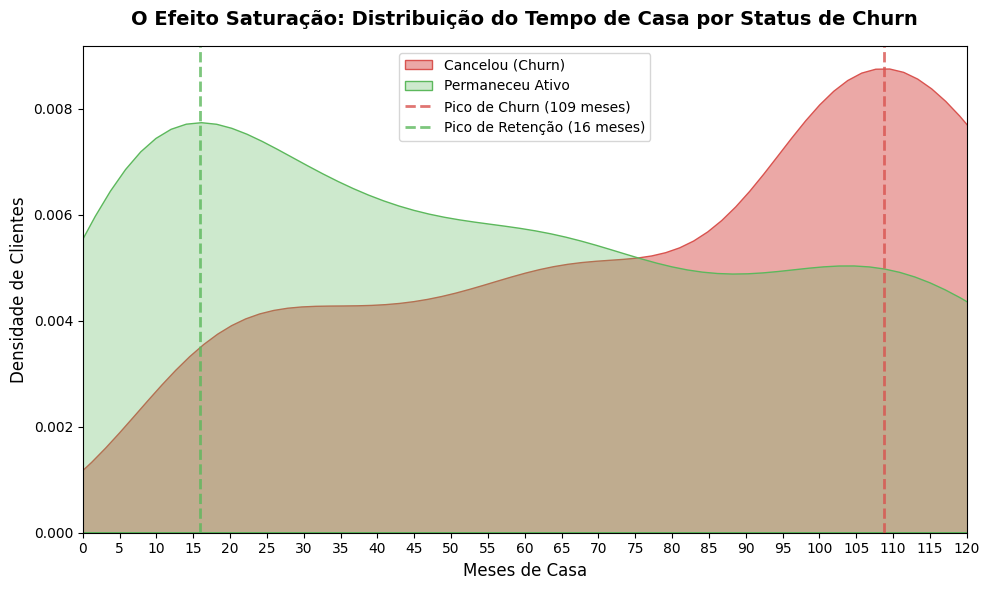

In [11]:
# Filtra os dados de cada grupo isolando os meses de casa
ativos = dataset[dataset['churn'] == 0]['meses_de_casa']
churns = dataset[dataset['churn'] == 1]['meses_de_casa']

# Grid de meses para o cálculo (0 a 120 meses)
valores_x = np.linspace(0, 120, 1000)

# CÁLCULO DO PICO DA CURVA VERDE (ATIVOS)
estimador_verde = gaussian_kde(ativos)
densidade_verde = estimador_verde(valores_x)
pico_verde      = valores_x[np.argmax(densidade_verde)]

# CÁLCULO DO PICO DA CURVA VERMELHA (CHURN)
estimador_vermelho = gaussian_kde(churns)
densidade_vermelha = estimador_vermelho(valores_x)
pico_vermelho      = valores_x[np.argmax(densidade_vermelha)]

# PLOTAGEM DO GRÁFICO
plt.figure(figsize=(10, 6))

# Filtra e plota a distribuição do tempo de casa para os dois grupos
sns.kdeplot(data=dataset[dataset['churn'] == 1],
            x='meses_de_casa',
            label='Cancelou (Churn)',
            fill=True,
            color='#d9534f',
            alpha=0.5)

sns.kdeplot(data=dataset[dataset['churn'] == 0],
            x='meses_de_casa',
            label='Permaneceu Ativo',
            fill=True,
            color='#5cb85c',
            alpha=0.3)

plt.title('O Efeito Saturação: Distribuição do Tempo de Casa por Status de Churn',
          fontsize=14,
          fontweight='bold',
          pad=15)
plt.xlabel('Meses de Casa', fontsize=12)
plt.ylabel('Densidade de Clientes', fontsize=12)
plt.xlim(0, 120)
plt.xticks(np.arange(0, 121, step=5))

# LINHAS VERTICAIS DOS PICOS
# Linha do Churn (Vermelha)
plt.axvline(pico_vermelho,
            color='#d9534f',
            linestyle='--',
            linewidth=2,
            alpha=0.8,
            label=f'Pico de Churn ({pico_vermelho:.0f} meses)')

# Linha dos Ativos (Verde)
plt.axvline(pico_verde,
            color='#5cb85c',
            linestyle='--',
            linewidth=2,
            alpha=0.8,
            label=f'Pico de Retenção ({pico_verde:.0f} meses)')

plt.legend(loc='upper center', fontsize=10)
plt.tight_layout()
plt.show()

In [12]:
# O Pico de Retenção (17 meses)
# A maior concentração de clientes ativos na sua base hoje é de empresas
# que têm por volta de 1 ano e 4 meses de casa
# O que o gráfico mostra:
# A montanha verde tem seu ápice bem cedo, por volta de 1 ano e 4 meses.
# O Insight de Negócio:
# Significa que o seu processo de venda, o onboarding (implantação)
# e os primeiros meses de uso são extremamente eficientes. O cliente entra, o sistema resolve
# a dor imediata dele e a equipe dele usa o software ativamente. Nessa fase, a densidade de
# clientes ativos é muito maior do que a de cancelados. É o cliente no auge do engajamento.

# O Pico de Churn (108 meses)
# O que o gráfico mostra:
# O maior pico de cancelamentos da história da sua empresa acontece
# assustadoramente tarde, aos 9 anos de relacionamento.
# O Insight de Negócio:
# Isso é o clássico "Churn por Saturação ou Legado".
# Esse cliente não saiu porque o suporte foi ruim hoje ou porque o boleto atrasou.
# Ele saiu porque, depois de quase uma década usando a mesma ferramenta, o processo dele mudou,
# a empresa dele cresceu, e o seu software parou de acompanhar essa evolução.
# O cliente cansa de pedir melhorias, começa a achar o sistema "antigo" ou "pesado" comparado
# com soluções mais novas do mercado, e a concorrência bate na porta prometendo modernidade.
# É um churn silencioso que vem sendo cozinhado há anos.

# Análise de Correlação e Multicolinearidade

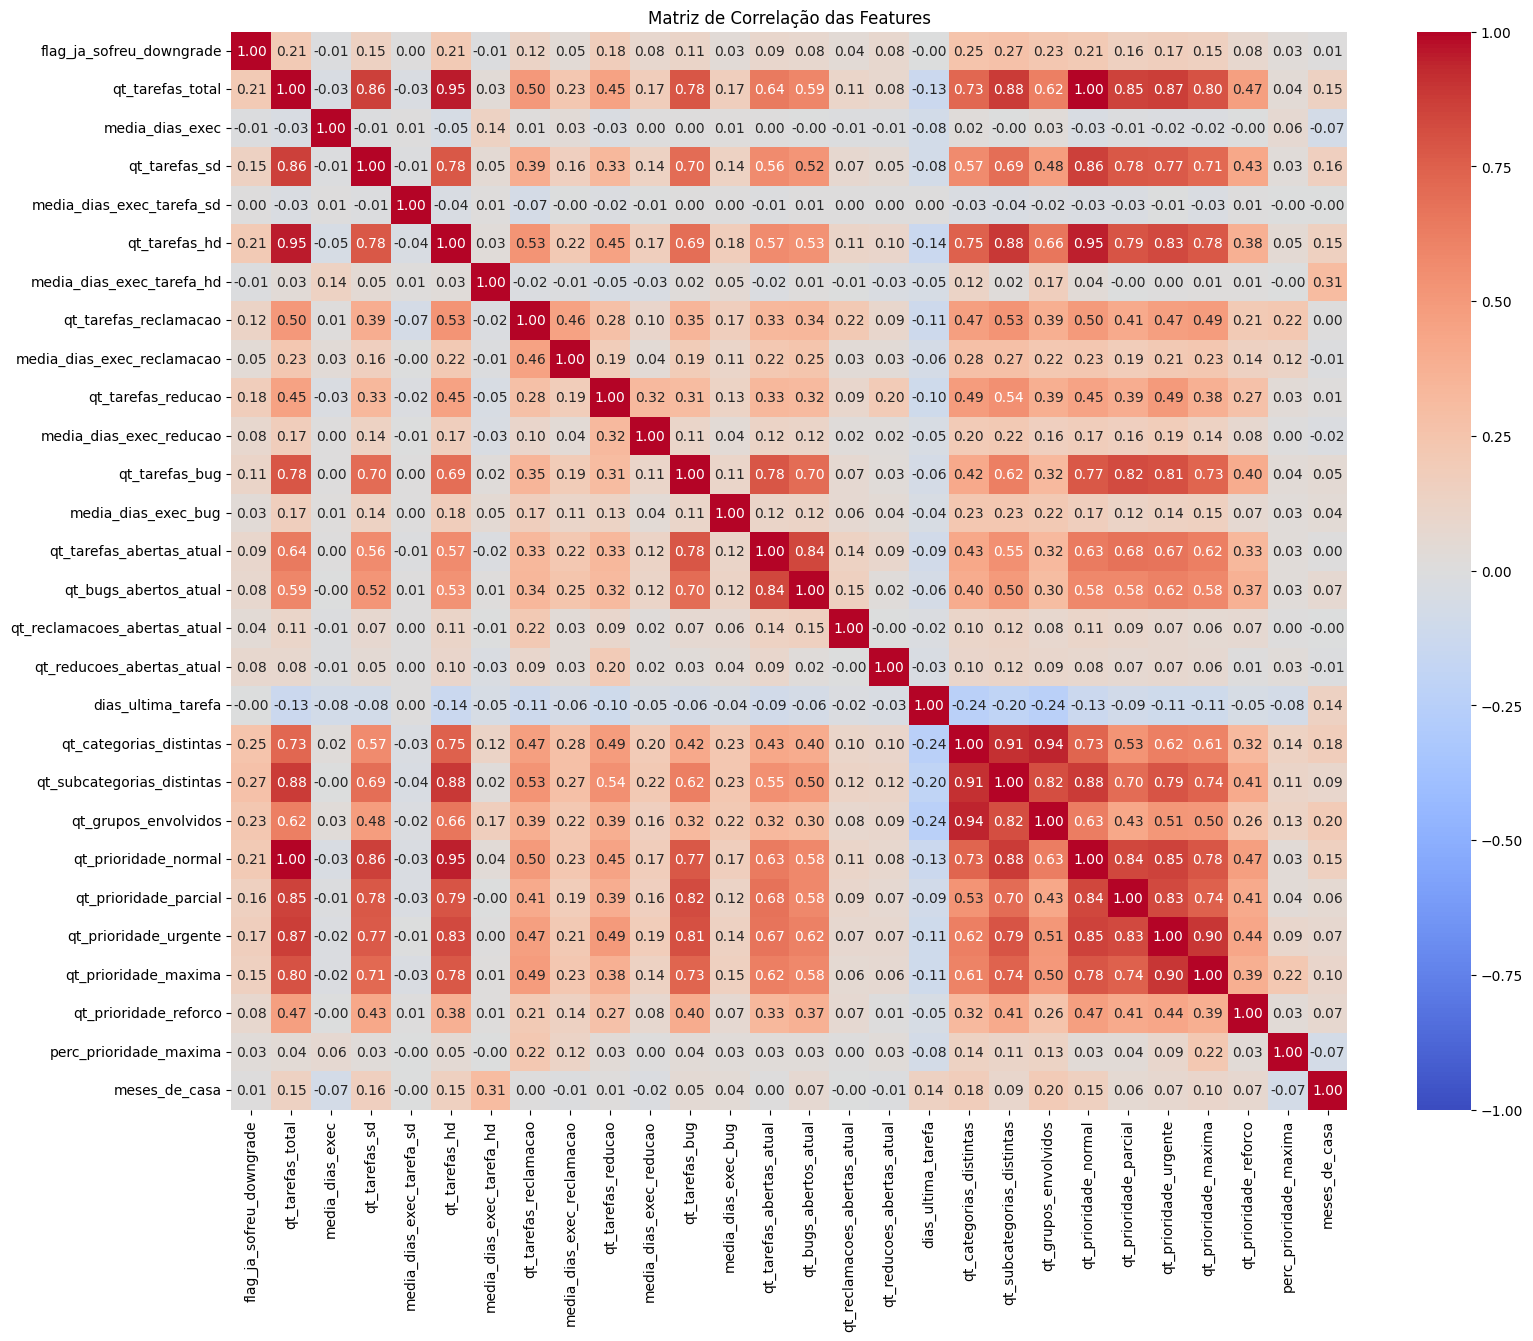

In [13]:
# Calculando a matriz de correlação de Pearson
plt.figure(figsize=(18, 14))
matrix_corr = X.corr()

# Plotando o Heatmap
sns.heatmap(matrix_corr, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Matriz de Correlação das Features")
plt.show()

In [14]:
# Filtrando correlações altas
upper_tri = matrix_corr.where(np.triu(np.ones(matrix_corr.shape), k=1).astype(bool))
to_drop_1 = [column for column in upper_tri.columns if any(abs(upper_tri[column]) >= 0.75)]
print(f"Sugestão de variáveis para exclusão por alta correlação:\n{to_drop_1}")

Sugestão de variáveis para exclusão por alta correlação:
['qt_tarefas_sd', 'qt_tarefas_hd', 'qt_tarefas_bug', 'qt_tarefas_abertas_atual', 'qt_bugs_abertos_atual', 'qt_subcategorias_distintas', 'qt_grupos_envolvidos', 'qt_prioridade_normal', 'qt_prioridade_parcial', 'qt_prioridade_urgente', 'qt_prioridade_maxima']


# Features Descartadas

In [15]:
tarefas_por_prioridade = list(X.filter(regex='qt_prioridade').columns)

colunas_alta_corr = [
    'qt_tarefas_total',
    'qt_subcategorias_distintas',
    'qt_grupos_envolvidos',
    'qt_tarefas_abertas_atual',
    # 'qt_tarefas_hd',
    'meses_de_casa',
    'perc_prioridade_maxima'
    ]

to_drop_completo = tarefas_por_prioridade + colunas_alta_corr

In [16]:
X_limpo = X.drop(columns=to_drop_completo)
X_limpo.head()

,flag_ja_sofreu_downgrade,media_dias_exec,qt_tarefas_sd,media_dias_exec_tarefa_sd,qt_tarefas_hd,media_dias_exec_tarefa_hd,qt_tarefas_reclamacao,media_dias_exec_reclamacao,qt_tarefas_reducao,media_dias_exec_reducao,qt_tarefas_bug,media_dias_exec_bug,qt_bugs_abertos_atual,qt_reclamacoes_abertas_atual,qt_reducoes_abertas_atual,dias_ultima_tarefa,qt_categorias_distintas
0,0,64.5000,1,26.0000,0,0.0000,0,0.0,0,0.0,0,0.0000,0,0,0,0,3
1,0,21.5878,97,16.8557,201,8.1055,0,0.0,1,0.0,43,60.6286,7,0,0,11,39
2,0,12.2727,6,2.0000,46,5.4783,0,0.0,0,0.0,0,0.0000,0,0,0,265,16
3,0,22.6316,1,12.0000,10,4.7000,0,0.0,0,0.0,0,0.0000,0,0,0,149,9
4,0,48.8854,67,33.0896,20,12.2500,0,0.0,0,0.0,0,0.0000,0,0,0,460,21


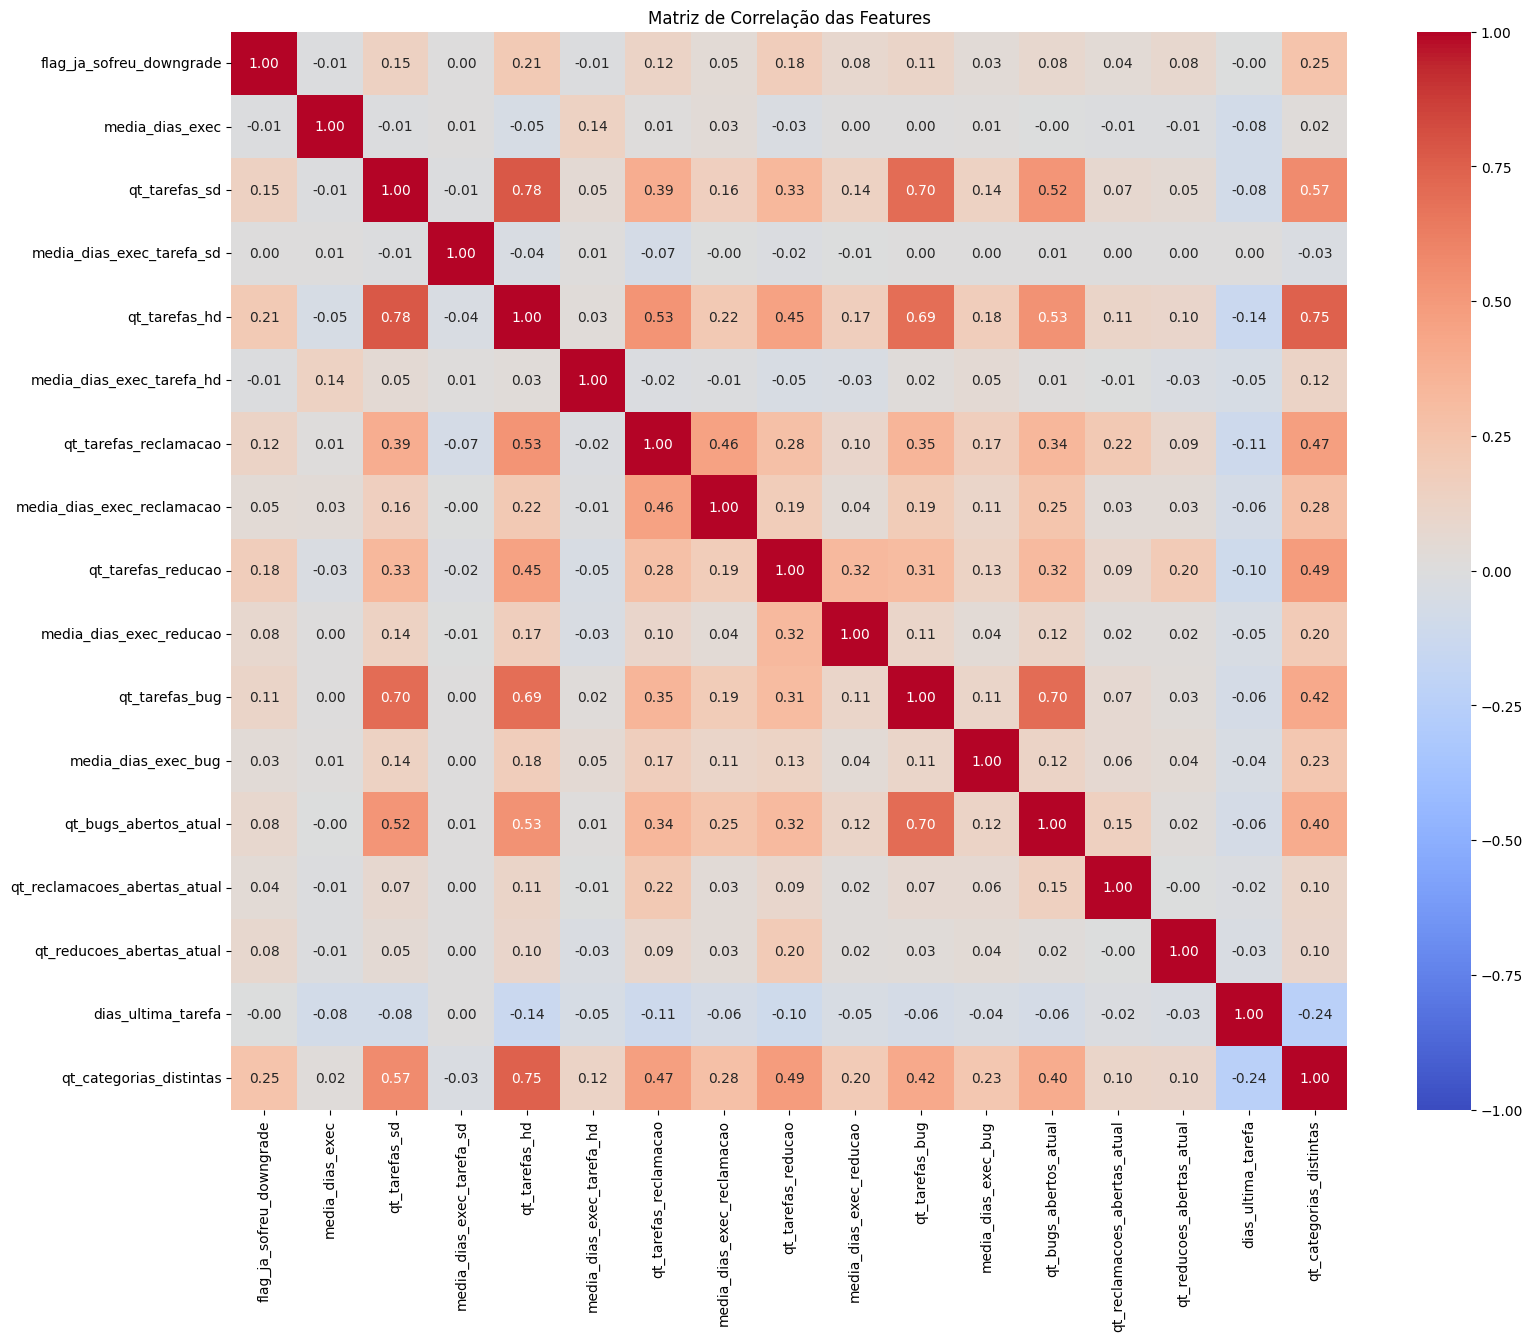

In [17]:
# Calculando a matriz de correlação de Pearson
plt.figure(figsize=(18, 14))
matrix_corr_limpa = X_limpo.corr()

# Plotando o Heatmap
sns.heatmap(matrix_corr_limpa, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Matriz de Correlação das Features")
plt.show()

In [18]:
# Filtrando correlações altas
upper_tri_limpo = matrix_corr_limpa.where(np.triu(np.ones(matrix_corr_limpa.shape), k=1).astype(bool))

to_drop_2 = [column for column in upper_tri_limpo.columns if any(abs(upper_tri_limpo[column]) >= 0.75)]

print(f"Sugestão de variáveis para exclusão por alta correlação: {to_drop_2}")

Sugestão de variáveis para exclusão por alta correlação: ['qt_tarefas_hd']


# Análise de Outliers

In [19]:
# DataFrame com as colunas que restaram após o drop de correlação
df_features = X_limpo.copy()

print("--- ANÁLISE QUANTITATIVA DE OUTLIERS (MÉTODO IQR) ---")
print(f"{'Métrica / Feature':<40} | {'qt Outliers':<12} | {'Porcentagem':<12}")
print("-" * 62)

colunas_com_outliers_criticos = []

for col in df_features.columns:
    # Ignora colunas que já são flags binárias (0 ou 1), pois nelas não existem outliers estatísticos
    if df_features[col].nunique() <= 2:
        continue

    Q1 = df_features[col].quantile(0.25)
    Q3 = df_features[col].quantile(0.75)
    IQR = Q3 - Q1

    # Definição estatística de Outlier: além de 1.5 vezes o IQR
    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR

    outliers = df_features[(df_features[col] < limite_inferior) | (df_features[col] > limite_superior)]
    total_outliers = len(outliers)
    porcentagem = (total_outliers / len(df_features)) * 100

    print(f"{col:<40} | {total_outliers:<12} | {porcentagem:.2f}%")

    # Se mais de 5% dos dados forem outliers, ou se houver um volume absoluto considerável
    if porcentagem > 5.0:
        colunas_com_outliers_criticos.append(col)

--- ANÁLISE QUANTITATIVA DE OUTLIERS (MÉTODO IQR) ---
Métrica / Feature                        | qt Outliers  | Porcentagem 
--------------------------------------------------------------
media_dias_exec                          | 361          | 7.68%
qt_tarefas_sd                            | 569          | 12.10%
media_dias_exec_tarefa_sd                | 307          | 6.53%
qt_tarefas_hd                            | 581          | 12.36%
media_dias_exec_tarefa_hd                | 175          | 3.72%
qt_tarefas_reclamacao                    | 498          | 10.59%
media_dias_exec_reclamacao               | 465          | 9.89%
qt_tarefas_reducao                       | 404          | 8.59%
media_dias_exec_reducao                  | 374          | 7.96%
qt_tarefas_bug                           | 748          | 15.91%
media_dias_exec_bug                      | 650          | 13.83%
qt_bugs_abertos_atual                    | 173          | 3.68%
qt_reclamacoes_abertas_atual           

In [20]:
# Dedivo à presença de outliers críticos,
# as variáveis numéricas serão padronizadas usando o RobustScaler,
# que é mais resistente a valores extremos para padronizar as features numéricas.

# Divisão de Treino/Teste e Padronização (Scaling)

In [21]:
# Separando os dados em Treino (75%) e Teste (25%) garantindo a mesma proporção de Churn (stratify)
X_train, X_test, y_train, y_test = train_test_split(
    X_limpo, y, test_size=0.30, random_state=42, stratify=y
)

# Padronizando as variáveis (Z-score: Média=0, Desvio Padrão=1)
scaler = RobustScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f"Base de Treino: {X_train_scaled.shape[0]} amostras")
print(f"Base de Teste:  {X_test_scaled.shape[0]} amostras")

Base de Treino: 3290 amostras
Base de Teste:  1411 amostras


# Regressão Logística

In [22]:
# Treinando a Regressão Logística
modelo_reglog = LogisticRegression(max_iter=1000, random_state=42)
modelo_reglog.fit(X_train_scaled, y_train)

# Predições
y_pred_reglog  = modelo_reglog.predict(X_test_scaled)
y_probs_reglog = modelo_reglog.predict_proba(X_test_scaled)[:, 1] # Probabilidade de ser 1 (Churn)

In [23]:
# Criamos uma cópia do X_test original (sem escala) para manter as colunas legíveis
df_validacao = X_test.copy()

# Resgatamos o 'cod_cliente' do dataset original usando o mesmo índice do teste
df_validacao['cod_cliente'] = dataset.loc[X_test.index, 'cod_cliente']

# Adicionamos as colunas do Target Real, da Predição e da Probabilidade
df_validacao['churn_real'] = y_test
df_validacao['churn_predito'] = y_pred_reglog
df_validacao['probabilidade_churn'] = (y_probs_reglog * 100).astype(float) # Convertendo para porcentagem

# Criamos uma coluna de diagnóstico para filtrar erros e acertos facilmente
df_validacao['diagnostico'] = np.where(
    (df_validacao['churn_real'] == 1) & (df_validacao['churn_predito'] == 1), 'Verdadeiro Positivo (Acertou Churn)',
    np.where(
        (df_validacao['churn_real'] == 0) & (df_validacao['churn_predito'] == 0), 'Verdadeiro Negativo (Acertou Ativo)',
        np.where(
            (df_validacao['churn_real'] == 0) & (df_validacao['churn_predito'] == 1), 'Falso Positivo (Alarme Falso)', 
            'Falso Negativo (Churn Invisível)'
        )
    )
)

# Reorganiza as colunas para deixar os IDs e Resultados no começo do DataFrame
colunas_ordenadas = ['cod_cliente', 'churn_real', 'churn_predito', 'probabilidade_churn', 'diagnostico']
df_validacao = df_validacao[colunas_ordenadas].reset_index(drop=True)
# df_validacao.to_csv('dados_brutos\\validacao_modelo_reglog.csv', index=False)
df_validacao.head()

,cod_cliente,churn_real,churn_predito,probabilidade_churn,diagnostico
0,35930,1,1,64.763409,Verdadeiro Positivo (Acertou Churn)
1,17576,1,1,83.504006,Verdadeiro Positivo (Acertou Churn)
2,4490,0,0,9.775974,Verdadeiro Negativo (Acertou Ativo)
3,35646,1,1,97.628007,Verdadeiro Positivo (Acertou Churn)
4,13555,0,0,0.289101,Verdadeiro Negativo (Acertou Ativo)


## Métricas

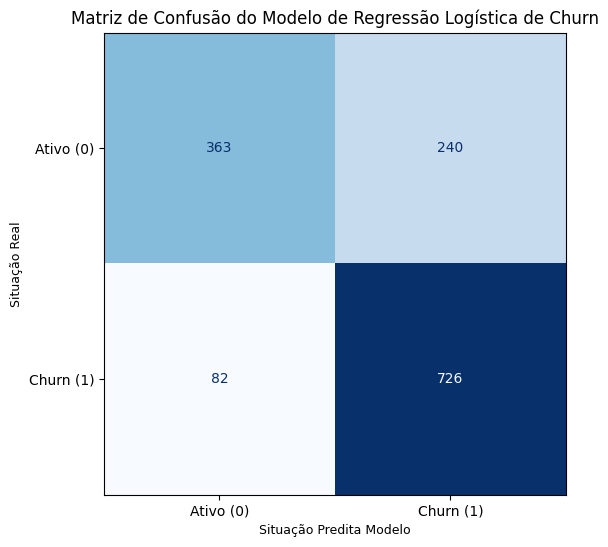

In [24]:
# Matriz de Confusão
cm_reglog = confusion_matrix(y_test, y_pred_reglog)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_reglog, display_labels=['Ativo (0)', 'Churn (1)'])
fig, ax = plt.subplots(figsize=(6, 6))
ax.grid(False)

disp.plot(cmap='Blues', values_format='d', colorbar=False, ax=ax) # 'd' força a exibição como número inteiro

plt.title('Matriz de Confusão do Modelo de Regressão Logística de Churn')
plt.ylabel('Situação Real', fontsize=9)
plt.xlabel('Situação Predita Modelo', fontsize=9)
plt.show()

In [25]:
# Relatório de Classificação (Precision, Recall, F1-Score)
print("--- RELATÓRIO DE CLASSIFICAÇÃO ---")
print(classification_report(y_test, y_pred_reglog))

--- RELATÓRIO DE CLASSIFICAÇÃO ---
              precision    recall  f1-score   support

           0       0.82      0.60      0.69       603
           1       0.75      0.90      0.82       808

    accuracy                           0.77      1411
   macro avg       0.78      0.75      0.76      1411
weighted avg       0.78      0.77      0.76      1411



ROC AUC Score: 0.84


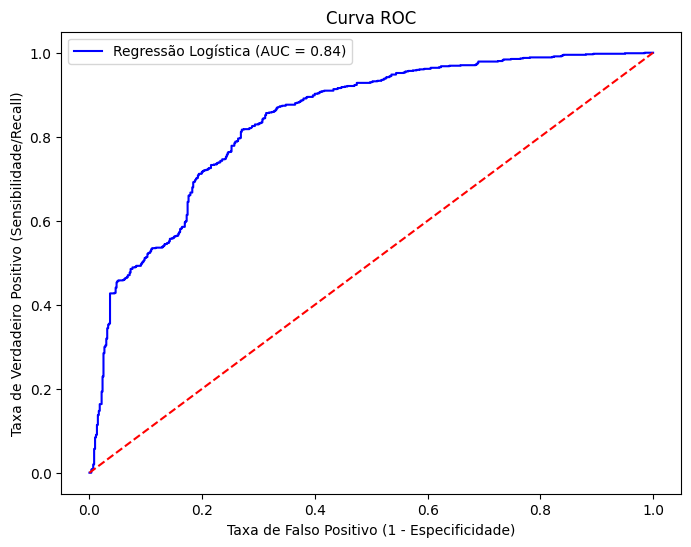

In [26]:
# ROC AUC Score
auc = roc_auc_score(y_test, y_probs_reglog)
print(f"ROC AUC Score: {auc:.2f}")

# Plotando a Curva ROC
fpr, tpr, thresholds = roc_curve(y_test, y_probs_reglog)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', label=f'Regressão Logística (AUC = {auc:.2f})')
plt.plot([0, 1], [0, 1], color='red', linestyle='--')
plt.xlabel('Taxa de Falso Positivo (1 - Especificidade)')
plt.ylabel('Taxa de Verdadeiro Positivo (Sensibilidade/Recall)')
plt.title('Curva ROC')
plt.legend()
plt.show()

## Salva Modelo

In [27]:
joblib.dump(modelo_reglog, 'src\\modelo_reglog.pkl')

['src\\modelo_reglog.pkl']

## Importância das Features

In [28]:
# Ajustando os dados para o Statsmodels
# O statsmodels precisa explicitamente da coluna de intercepto (constante)
# X_train_scaled deve ser um DataFrame com os nomes das colunas
df_X_train_scaled   = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_train_sm          = sm.add_constant(df_X_train_scaled)
X_train_sm          = pd.DataFrame(X_train_sm, columns=['const'] + list(df_X_train_scaled.columns))

# Treinando a Regressão Logística Estatística
model_sm = sm.Logit(y_train, X_train_sm).fit(method='bfgs', maxiter=1000)

# Extraindo Coeficientes e p-valores
df_importance = pd.DataFrame({
    'Feature':      df_X_train_scaled.columns,
    'Coefficient':  model_sm.params.drop('const'),
    'p_value':      model_sm.pvalues.drop('const')
}).reset_index(drop=True)

# Criando critério de significância estatística (p-valor < 0.05)
df_importance['Significativo'] = df_importance['p_value'].apply(
    lambda x: 'Sim (p < 0.05)' if x < 0.05 else 'Não (Irrelevante)'
    )

# Exibir tabela textual complementar
print(df_importance[['Feature', 'Coefficient', 'p_value', 'Significativo']].to_string(index=False))

Optimization terminated successfully.
         Current function value: 0.475834
         Iterations: 98
         Function evaluations: 106
         Gradient evaluations: 102
                     Feature  Coefficient      p_value     Significativo
    flag_ja_sofreu_downgrade  -121.690798 9.992752e-01 Não (Irrelevante)
             media_dias_exec     0.215230 1.482085e-07    Sim (p < 0.05)
               qt_tarefas_sd     0.322879 3.608611e-13    Sim (p < 0.05)
   media_dias_exec_tarefa_sd    -0.040671 1.374787e-01 Não (Irrelevante)
               qt_tarefas_hd    -0.488095 5.685106e-09    Sim (p < 0.05)
   media_dias_exec_tarefa_hd     0.976090 1.862210e-31    Sim (p < 0.05)
       qt_tarefas_reclamacao     0.438104 3.172553e-03    Sim (p < 0.05)
  media_dias_exec_reclamacao    -0.002654 5.711062e-01 Não (Irrelevante)
          qt_tarefas_reducao    -0.102471 5.841478e-01 Não (Irrelevante)
     media_dias_exec_reducao    -0.047713 4.777845e-02    Sim (p < 0.05)
              qt_tarefa

c:\Users\victor.payan\Downloads\venv\Lib\site-packages\statsmodels\discrete\discrete_model.py:2385: RuntimeWarning: overflow encountered in exp
  return 1/(1+np.exp(-X))
c:\Users\victor.payan\Downloads\venv\Lib\site-packages\statsmodels\discrete\discrete_model.py:2443: RuntimeWarning: divide by zero encountered in log
  return np.sum(np.log(self.cdf(q * linpred)))
c:\Users\victor.payan\Downloads\venv\Lib\site-packages\statsmodels\discrete\discrete_model.py:2385: RuntimeWarning: overflow encountered in exp
  return 1/(1+np.exp(-X))
c:\Users\victor.payan\Downloads\venv\Lib\site-packages\statsmodels\discrete\discrete_model.py:2443: RuntimeWarning: divide by zero encountered in log
  return np.sum(np.log(self.cdf(q * linpred)))


## Odds_Ratio

In [29]:
# Coeficientes de probabilidade
# Acima de 1.0: Aumenta a chance de Churn
# Abaixo de 1.0: Reduz a chance de Churn

# Extraindo coeficientes
coeficientes_churn_reglog = pd.DataFrame({
    'Feature': X_limpo.columns,
    'Coeficiente': modelo_reglog.coef_[0]
})

# Calculando a Razão de Chance (Odds Ratio)
coeficientes_churn_reglog['Odds_Ratio'] = coeficientes_churn_reglog['Coeficiente'].apply(lambda x: math.exp(x))

# Calcula o impacto percentual dependendo se o valor está acima ou abaixo de 1.0
coeficientes_churn_reglog['Impacto_Percentual'] = np.where(
    coeficientes_churn_reglog['Odds_Ratio'] >= 1.0,
    (coeficientes_churn_reglog['Odds_Ratio'] - 1) * 100,
    (1 - coeficientes_churn_reglog['Odds_Ratio']) * 100
)

# Cria uma coluna de texto formatada para facilitar a leitura no relatório
coeficientes_churn_reglog['Impacto_Formatado'] = np.where(
    coeficientes_churn_reglog['Odds_Ratio'] >= 1.0,
    "+" + coeficientes_churn_reglog['Impacto_Percentual'].round(2).astype(str) + "% (Aumento de Risco)",
    "-" + coeficientes_churn_reglog['Impacto_Percentual'].round(2).astype(str) + "% (Redução de Risco)"
)

coeficientes_churn_reglog = coeficientes_churn_reglog.sort_values(by='Coeficiente', ascending=False).reset_index(drop=True)
# coeficientes_churn_reglog.to_csv('dados_resultado\\coeficientes_churn_reglog.csv', index=False)
coeficientes_churn_reglog

,Feature,Coeficiente,Odds_Ratio,Impacto_Percentual,Impacto_Formatado
0,media_dias_exec_tarefa_hd,0.961764,2.616307,161.630662,+161.63% (Aumento de Risco)
1,qt_tarefas_reclamacao,0.409946,1.506736,50.673569,+50.67% (Aumento de Risco)
2,qt_tarefas_sd,0.311593,1.365599,36.559927,+36.56% (Aumento de Risco)
3,media_dias_exec,0.213503,1.238007,23.800731,+23.8% (Aumento de Risco)
4,media_dias_exec_bug,-0.001971,0.998031,0.196918,-0.2% (Redução de Risco)
5,media_dias_exec_reclamacao,-0.002528,0.997475,0.252481,-0.25% (Redução de Risco)
6,media_dias_exec_tarefa_sd,-0.039701,0.961077,3.892324,-3.89% (Redução de Risco)
7,media_dias_exec_reducao,-0.045858,0.955177,4.482279,-4.48% (Redução de Risco)
8,qt_tarefas_bug,-0.065110,0.936964,6.303587,-6.3% (Redução de Risco)
9,qt_reclamacoes_abertas_atual,-0.100836,0.904081,9.591912,-9.59% (Redução de Risco)


## Alarmes Falsos (Falsos Positivos)

In [30]:
df_fp = df_validacao[df_validacao['diagnostico'] == 'Falso Positivo (Alarme Falso)'].sort_values(by='probabilidade_churn', ascending=False)
# df_fp.to_csv('dados_resultado\\falsos_positivos_churn.csv', index=False)
df_fp.head()

,cod_cliente,churn_real,churn_predito,probabilidade_churn,diagnostico
603,35926,0,1,100.000000,Falso Positivo (Alarme Falso)
1084,11109,0,1,100.000000,Falso Positivo (Alarme Falso)
66,45615,0,1,99.372425,Falso Positivo (Alarme Falso)
1260,46649,0,1,99.289552,Falso Positivo (Alarme Falso)
927,43385,0,1,98.341139,Falso Positivo (Alarme Falso)


## Churns Invisíveis (Falsos Negativos)

In [31]:
df_fn = df_validacao[df_validacao['diagnostico'] == 'Falso Negativo (Churn Invisível)'].sort_values(by='probabilidade_churn', ascending=True)
# df_fn.to_csv('dados_resultado\\falsos_negativos_churn.csv', index=False)
df_fn.head()

,cod_cliente,churn_real,churn_predito,probabilidade_churn,diagnostico
555,43337,1,0,0.000081,Falso Negativo (Churn Invisível)
619,24938,1,0,0.081680,Falso Negativo (Churn Invisível)
847,45637,1,0,0.952440,Falso Negativo (Churn Invisível)
183,46175,1,0,1.303619,Falso Negativo (Churn Invisível)
1173,9116,1,0,2.521036,Falso Negativo (Churn Invisível)


## Análises de Negócio

In [32]:
# dias_ultima_tarefa (Coef: 1.69 | Odds: 5.42)
# Análise: É o maior preditor isolado de Churn da sua empresa.
# Se o cliente para de abrir tarefas, ele está morrendo operacionalmente.
# A cada salto de desvio padrão na recência sem interagir com o
# suporte/operação, a chance dele cancelar multiplica por 5,42.

# Validação nos Erros: Olhando o arquivo de falsos_positivos_churn.csv,
# o cliente 35954 (que o modelo achava que era churn com 98% de certeza, mas continua ativo)
# está há 1.688 dias sem abrir uma única tarefa. Operacionalmente esse cliente está abandonado,
# o modelo está certíssimo em alertar risco crítico.

In [33]:
# meses_de_casa (Coef: 0.83 | Odds: 2.31)
# Análise Paradoxal: Em muitos mercados SaaS, quanto mais tempo de casa, menor o churn.
# Aqui acontece o oposto: clientes mais antigos têm mais chance de cancelar (Odds: 2.31).

# O Diagnóstico de Negócio: Isso aponta para obsolescência de produto ou fadiga de relacionamento.
# Clientes antigos (como vimos no cliente 17029 de 2011) acumulam processos pesados e, se o produto
# não evoluir com eles, eles viram alvo fácil de concorrentes mais modernos.

In [34]:
# qt_tarefas_reducao (Odds: 1.10) e qt_tarefas_bug (Odds: 1.06)
# Análise: Ambas empurram o cliente para a porta de saída.
# O atrito técnico (bug) e o sintoma claro de encolhimento de escopo comercial
# (reducao) aumentam o risco.
# Cada bug aberto deixa o cliente estatisticamente 6% mais propenso ao Churn total no futuro.

In [35]:
# flg_ja_sofreu_downgrade (Coef: -3.50 | Odds: 0.03)
# Análise: Clientes que já cancelaram contratos no passado, mas mantiveram outros ativos,
# possuem uma chance de Churn Real 97% menor (1 - 0.03) do que os outros.

# O Diagnóstico de Negócio: O downgrade funciona como uma válvula de escape financeira.
# O cliente ajusta o bolso à realidade dele, mas escolhe continuar na sua empresa.
# Ele já passou pelo momento de crise e decidiu ficar. É um grupo resiliente.

In [36]:
# qt_categorias_distintas (Coef: -1.94 | Odds: 0.14)
# Análise: O maior fator de retenção do seu produto.
# Clientes que usam muitas categorias diferentes têm o risco de Churn reduzido em 86% (1 - 0.14).

# O Diagnóstico de Negócio: Isso se chama Aderência (Stickiness).
# Se o cliente usa o sistema apenas para uma coisa (ex: só abre tarefa de suporte),
# ele te troca fácil. Se ele usa múltiplas categorias
# o seu software está integrado na cultura dele. Desplugá-lo da empresa dói demais.

In [37]:
# tarefas_90d (Coef: -0.56 | Odds: 0.56)
# Análise: Atividade recente protege.
# Clientes com alto volume nos últimos 90 dias têm seu risco
# reduzido quase pela metade (Odds: 0.56). É o oposto complementar da recência.

In [38]:
# perc_prioridade_maxima (Odds: 1.001)
# Análise: O impacto é praticamente nulo na decisão final.
# Por que isso acontece se tarefas urgentes parecem críticas?

# O Diagnóstico de Negócio: Olhando o arquivo de falsos_negativos_churn.csv
# (onde o modelo errou e o cliente cancelou mesmo parecendo saudável), o cliente 21584
# tinha uma volumetria imensa de tarefas (369), usava 31 categorias distintas e tinha um
# percentual baixo de prioridade máxima. O modelo foi enganado pelo excesso de uso.
# Clientes podem estar usando muito o sistema apenas porque ele é complexo ou confuso.

In [39]:
# O Plano de Ação Estratégico (O que entregar para a Diretoria)
# Com esse modelo, você acabou de criar as regras de ouro para o time de Sucesso do Cliente (CS):

# Gatilho de Saúde (Health Score): O time de CS precisa focar em Diversidade de Uso
# (qt_categorias_distintas). Se um cliente usa menos de X categorias, ele precisa de
# treinamento urgente para adotar novos módulos.

# Régua de Inatividade (dias_ultima_tarefa): Criar um alerta automatizado quando o
# cliente passar de X dias sem registrar movimentações, pois o risco se multiplica exponencialmente.

# Atenção aos Veteranos (meses_de_casa): Realizar auditorias e check-ups de satisfação
# focados em clientes com mais de 3 ou 4 anos de casa, pois eles tendem a dar churn
# por falta de atenção ou saturação.

In [40]:
# Validando a tese nos seus dados reais
# Se abrirmos o arquivo falsos_negativos_churn.csv que você gerou,
# conseguimos ver essa teoria acontecendo na prática. Veja o caso do cliente 40907:

# Ele deu Churn Real (churn_real = 1).

# O modelo calculou uma probabilidade minúscula de churn para ele (0.006), errando o diagnóstico.

# Por que o modelo errou? Olhe as métricas dele: nos últimos 90 dias, ele abriu apenas 6 tarefas.
# A recência dele era de 12 dias (relativamente baixa). Ele tinha apenas 1 bug aberto.

# Operacionalmente, a conta parecia "saudável" e sem problemas.
# Mas o que estava acontecendo de verdade?
# O cliente já tinha abandonado a ferramenta meses antes de formalizar o cancelamento, deixando uma
# volumetria baixíssima nos últimos 90 dias. Ele não reclamava porque já não se importava mais.

# O Insight de Ouro para o CS
# Um volume muito baixo de tarefas_90d é um sinal claro de falta de adoção.
# Cliente que não usa, não vê valor. E cliente que não vê valor, cancela sem fazer barulho.

# Salva Scaler

In [41]:
joblib.dump(scaler, 'src\\scaler_producao.pkl')

['src\\scaler_producao.pkl']

# Salva Features do Modelo

In [42]:
# Extrai os nomes das colunas na ordem exata do modelo
features_modelo = list(X_test.columns)

# Salva em um arquivo JSON
with open('src\\features_modelo.json', 'w', encoding='utf-8') as f:
    json.dump(features_modelo, f, ensure_ascii=False, indent=4)

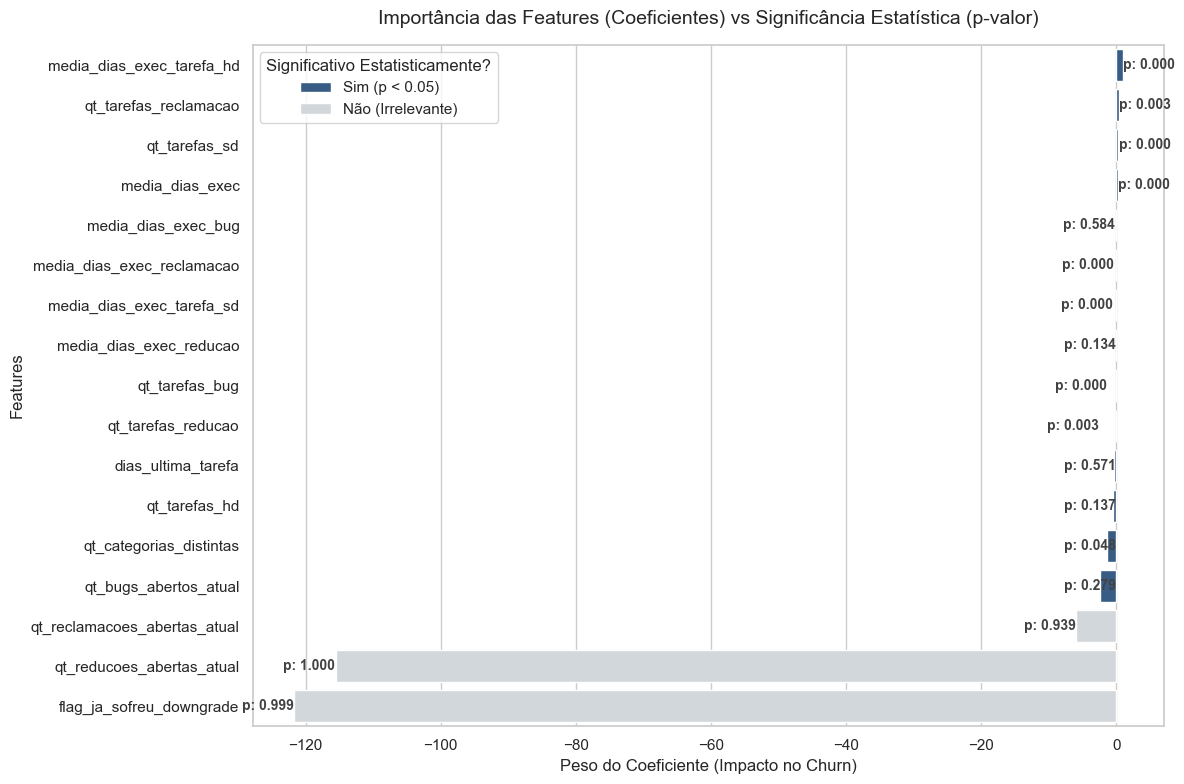

In [43]:
# Ordenar para o gráfico
df_importance = df_importance.sort_values(by='Coefficient', ascending=False)

# Plotando o Gráfico Gráfico de Importância
plt.figure(figsize=(12, 8))
sns.set_theme(style="whitegrid")

# Paleta de cores destacando o que é significativo ou não
palette_colors = {'Sim (p < 0.05)': '#2b5c8f', 'Não (Irrelevante)': '#cfd8dc'}

ax = sns.barplot(
    x='Coefficient',
    y='Feature',
    hue='Significativo',
    data=df_importance,
    palette=palette_colors,
    dodge=False
)

# Adicionando os valores dos p-valores como texto na barra
for p, label, coef in zip(ax.patches, df_importance['p_value'], df_importance['Coefficient']):
    offset = 0.02 if coef >= 0 else -0.07
    ax.annotate(f"p: {label:.3f}",
                (coef + offset, p.get_y() + p.get_height() / 2),
                va='center', ha='left' if coef >= 0 else 'right',
                fontsize=10, fontweight='bold', color='#424242')

plt.title('Importância das Features (Coeficientes) vs Significância Estatística (p-valor)', fontsize=14, pad=15)
plt.xlabel('Peso do Coeficiente (Impacto no Churn)', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.legend(title="Significativo Estatisticamente?")
plt.tight_layout()
plt.show()

In [44]:
# O Bug do flg_ja_sofreu_downgrade (P-valor = 1.0)O problema:
# Olhe o coeficiente dele: -69.70. Isso é um valor absurdamente gigante
# (em termos de escala linear logit). O p-valor cravado em 1.000 (o pior possível)
# avisa que ocorreu uma Separação Perfeita ou quase perfeita
# O que significa:
# Praticamente todos os clientes que sofreram downgrade continuam ativos (não deram churn).
# Quando uma variável prevê uma classe com quase 100% de certeza sozinha, a matemática da
# Regressão Logística entra em colapso (as matrizes de derivadas não convergem), gerando
# coeficientes bizarros e p-valores inúteis

# Multicolinearidade nos Tempos Médios de Atendimento
# Veja o comportamento emparelhado que suspeitávamos:
# Bugs: A quantidade de bugs (qt_tarefas_bug) é importantíssima (p < 0.05).
# Mas a média de tempo para resolver o bug (media_dias_exec_bug) deu p = 0.228 (Irrelevante).

# Reclamações: A quantidade de reclamações é crítica (p < 0.05).
# A média de tempo delas (media_dias_exec_reclamacao) deu p = 0.882 (Irrelevante).

# Redução: A quantidade de pedidos de redução deu p = 0.960 (Irrelevante)
# e a média de dias deu p = 0.074 (Irrelevante).
# O que significa: O volume bruto de problemas (bugs e reclamações abertas) é o que de fato
# estressa o cliente a ponto de dar churn. Adicionar o tempo médio de resolução para cada
# uma dessas caixas causou redundância de dados, inflou os p-valores e gerou ruído.

# Random Forest Classifier

In [45]:
from sklearn.ensemble import RandomForestClassifier

In [46]:
# Instanciando o modelo puro
modelo_rf = RandomForestClassifier(
    n_estimators=200,      # Quantidade de árvores na floresta
    max_depth=8,           # Limite sênior para não deixar a árvore "decorar" ruídos
    min_samples_leaf=5,    # Garante que cada folha tenha um grupo seguro de clientes
    random_state=42,
    n_jobs=-1              # Usa todos os núcleos do seu processador
)

modelo_rf.fit(X_train, y_train)

y_pred_rf = modelo_rf.predict(X_test)
y_probs_rf = modelo_rf.predict_proba(X_test)[:, 1]

## Salva Modelo

In [47]:
joblib.dump(modelo_rf, 'src\\modelo_rf.pkl')

['src\\modelo_rf.pkl']

## Métricas

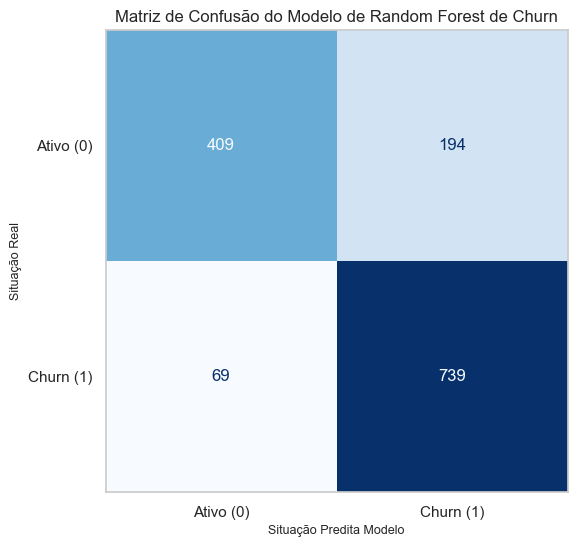

In [48]:
cm_rf = confusion_matrix(y_test, y_pred_rf)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=['Ativo (0)', 'Churn (1)'])
fig, ax = plt.subplots(figsize=(6, 6))
ax.grid(False)

disp.plot(cmap='Blues', values_format='d', colorbar=False, ax=ax) # 'd' força a exibição como número inteiro

plt.title('Matriz de Confusão do Modelo de Random Forest de Churn')
plt.ylabel('Situação Real', fontsize=9)
plt.xlabel('Situação Predita Modelo', fontsize=9)
plt.show()

In [49]:
# Relatório de Classificação (Precision, Recall, F1-Score)
print("--- RELATÓRIO DE CLASSIFICAÇÃO ---")
print(classification_report(y_test, y_pred_rf))

--- RELATÓRIO DE CLASSIFICAÇÃO ---
              precision    recall  f1-score   support

           0       0.86      0.68      0.76       603
           1       0.79      0.91      0.85       808

    accuracy                           0.81      1411
   macro avg       0.82      0.80      0.80      1411
weighted avg       0.82      0.81      0.81      1411



ROC AUC Score: 0.92


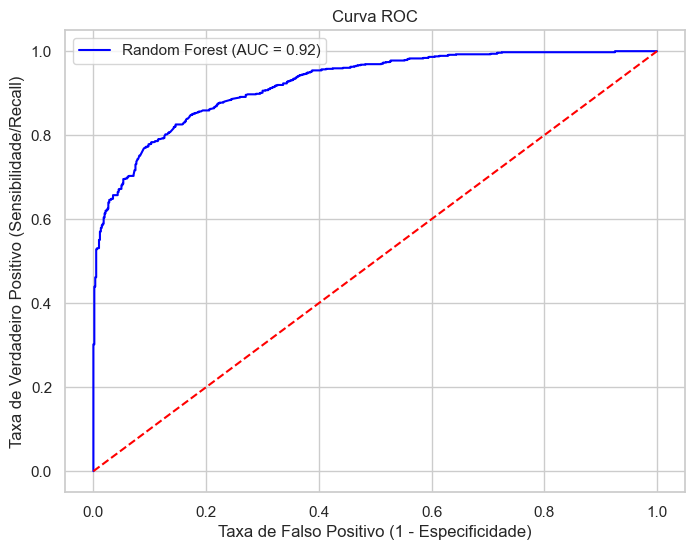

In [50]:
# ROC AUC Score
auc = roc_auc_score(y_test, y_probs_rf)
print(f"ROC AUC Score: {auc:.2f}")

# Plotando a Curva ROC
fpr, tpr, thresholds = roc_curve(y_test, y_probs_rf)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', label=f'Random Forest (AUC = {auc:.2f})')
plt.plot([0, 1], [0, 1], color='red', linestyle='--')
plt.xlabel('Taxa de Falso Positivo (1 - Especificidade)')
plt.ylabel('Taxa de Verdadeiro Positivo (Sensibilidade/Recall)')
plt.title('Curva ROC')
plt.legend()
plt.show()

## Importância das Features

In [51]:
# Extraindo a importância real das features (substituindo o .coef_)
importancia_features = modelo_rf.feature_importances_

# Montando o novo DataFrame sênior de impacto
coeficientes_churn_rf = pd.DataFrame({
    'Feature': X_limpo.columns,
    'Importancia_Absoluta': importancia_features # Guardamos o valor bruto para ordenação
})

# Transformando em porcentagem de impacto na decisão do modelo
coeficientes_churn_rf['Importancia_Percentual'] = (coeficientes_churn_rf['Importancia_Absoluta'] * 100).round(2)

# Cria o texto formatado indicando o peso da variável na tomada de decisão
coeficientes_churn_rf['Importancia_Formatado'] = coeficientes_churn_rf['Importancia_Percentual'].astype(str) + "% de peso no modelo"

# Ordena da feature MAIS importante para a MENOS importante
coeficientes_churn_rf = coeficientes_churn_rf.sort_values(by='Importancia_Absoluta', ascending=False).reset_index(drop=True)

# coeficientes_churn_rf.to_csv('dados_resultado\\importancia_churn_rf.csv', index=False)
coeficientes_churn_rf

,Feature,Importancia_Absoluta,Importancia_Percentual,Importancia_Formatado
0,dias_ultima_tarefa,0.294426,29.44,29.44% de peso no modelo
1,qt_tarefas_hd,0.180687,18.07,18.07% de peso no modelo
2,qt_categorias_distintas,0.159685,15.97,15.97% de peso no modelo
3,media_dias_exec_tarefa_hd,0.100029,10.00,10.0% de peso no modelo
4,qt_tarefas_bug,0.074007,7.40,7.4% de peso no modelo
5,media_dias_exec_bug,0.043536,4.35,4.35% de peso no modelo
6,qt_tarefas_sd,0.036176,3.62,3.62% de peso no modelo
7,media_dias_exec,0.032811,3.28,3.28% de peso no modelo
8,flag_ja_sofreu_downgrade,0.018177,1.82,1.82% de peso no modelo
9,media_dias_exec_tarefa_sd,0.018134,1.81,1.81% de peso no modelo


# XGBoost

In [52]:
from xgboost import XGBClassifier

In [53]:
# Instanciando o modelo puro
modelo_xgb = XGBClassifier(
    n_estimators=150,
    max_depth=5,            # Árvores do XGBoost são mais rasas por natureza
    learning_rate=0.05,     # Passos mais lentos para aprender com precisão
    random_state=42,
    eval_metric='logloss'   # Métrica padrão para probabilidade
)

modelo_xgb.fit(X_train, y_train)

y_pred_xgb  = modelo_xgb.predict(X_test)
y_probs_xgb = modelo_xgb.predict_proba(X_test)[:, 1]


## Salva Modelo

In [54]:
joblib.dump(modelo_xgb, 'src\\modelo_xgb.pkl')

['src\\modelo_xgb.pkl']

## Métricas

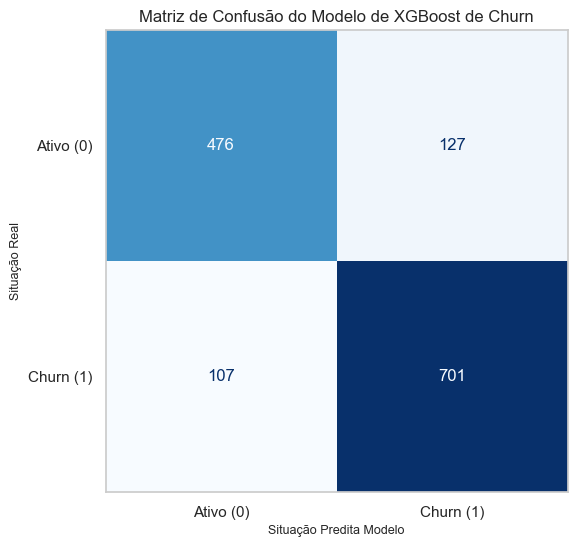

In [55]:
cm_xgb = confusion_matrix(y_test, y_pred_xgb)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_xgb, display_labels=['Ativo (0)', 'Churn (1)'])
fig, ax = plt.subplots(figsize=(6, 6))
ax.grid(False)

disp.plot(cmap='Blues', values_format='d', colorbar=False, ax=ax) # 'd' força a exibição como número inteiro

plt.title('Matriz de Confusão do Modelo de XGBoost de Churn')
plt.ylabel('Situação Real', fontsize=9)
plt.xlabel('Situação Predita Modelo', fontsize=9)
plt.show()

In [56]:
# Relatório de Classificação (Precision, Recall, F1-Score)
print("--- RELATÓRIO DE CLASSIFICAÇÃO ---")
print(classification_report(y_test, y_pred_xgb))

--- RELATÓRIO DE CLASSIFICAÇÃO ---
              precision    recall  f1-score   support

           0       0.82      0.79      0.80       603
           1       0.85      0.87      0.86       808

    accuracy                           0.83      1411
   macro avg       0.83      0.83      0.83      1411
weighted avg       0.83      0.83      0.83      1411



ROC AUC Score: 0.93


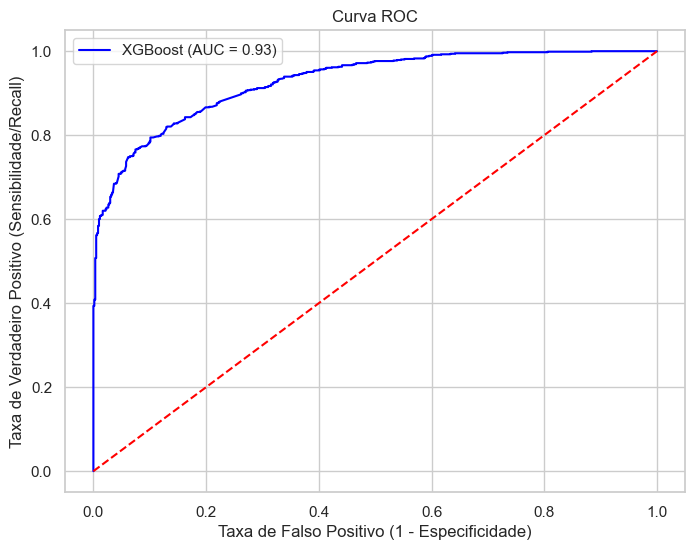

In [57]:
# ROC AUC Score
auc = roc_auc_score(y_test, y_probs_xgb)
print(f"ROC AUC Score: {auc:.2f}")

# Plotando a Curva ROC
fpr, tpr, thresholds = roc_curve(y_test, y_probs_xgb)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', label=f'XGBoost (AUC = {auc:.2f})')
plt.plot([0, 1], [0, 1], color='red', linestyle='--')
plt.xlabel('Taxa de Falso Positivo (1 - Especificidade)')
plt.ylabel('Taxa de Verdadeiro Positivo (Sensibilidade/Recall)')
plt.title('Curva ROC')
plt.legend()
plt.show()

## Importância das Features

In [58]:
# Extraindo a importância real das features do XGBoost
importancia_features_xgb = modelo_xgb.feature_importances_

# Montando o DataFrame de Impacto do XGBoost
coeficientes_churn_xgb = pd.DataFrame({
    'Feature': X_limpo.columns,
    'Importancia_Absoluta': importancia_features_xgb
})

# Transformando em porcentagem de impacto na decisão
coeficientes_churn_xgb['Importancia_Percentual'] = (coeficientes_churn_xgb['Importancia_Absoluta'] * 100).round(2)

# Criando o texto formatado para o relatório
coeficientes_churn_xgb['Importancia_Formatado'] = coeficientes_churn_xgb['Importancia_Percentual'].astype(str) + "% de peso no modelo"

# Ordenando da feature MAIS importante para a MENOS importante
coeficientes_churn_xgb = coeficientes_churn_xgb.sort_values(by='Importancia_Absoluta', ascending=False).reset_index(drop=True)

# Exibe o resultado na tela
coeficientes_churn_xgb

,Feature,Importancia_Absoluta,Importancia_Percentual,Importancia_Formatado
0,qt_tarefas_hd,0.176027,17.600000,17.6% de peso no modelo
1,dias_ultima_tarefa,0.168025,16.799999,16.8% de peso no modelo
2,qt_categorias_distintas,0.112189,11.220000,11.22% de peso no modelo
3,media_dias_exec_tarefa_hd,0.095433,9.540000,9.54% de peso no modelo
4,qt_tarefas_bug,0.078607,7.860000,7.86% de peso no modelo
5,flag_ja_sofreu_downgrade,0.076040,7.600000,7.6% de peso no modelo
6,qt_bugs_abertos_atual,0.067234,6.720000,6.72% de peso no modelo
7,qt_tarefas_reducao,0.046020,4.600000,4.6% de peso no modelo
8,media_dias_exec_reducao,0.043872,4.390000,4.39% de peso no modelo
9,media_dias_exec_bug,0.026564,2.660000,2.66% de peso no modelo


# Análise SHAP

In [59]:
import shap

--- VISÃO GLOBAL DE IMPACTO DAS FEATURES ---


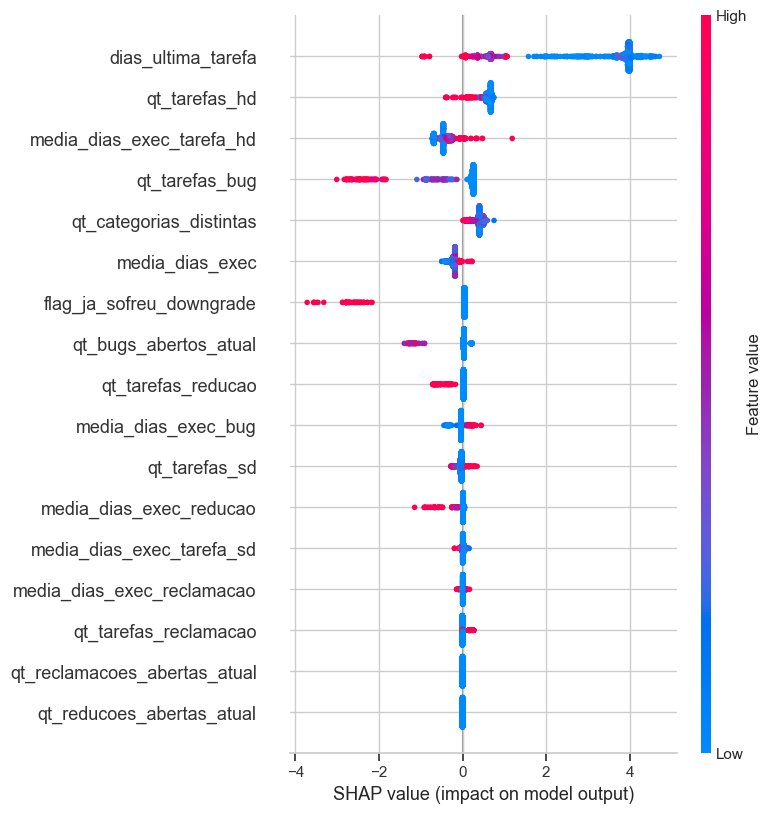


--- AUDITORIA INDIVIDUAL: POR QUE ESTE CLIENTE RECEBEU ESSE SCORE? ---


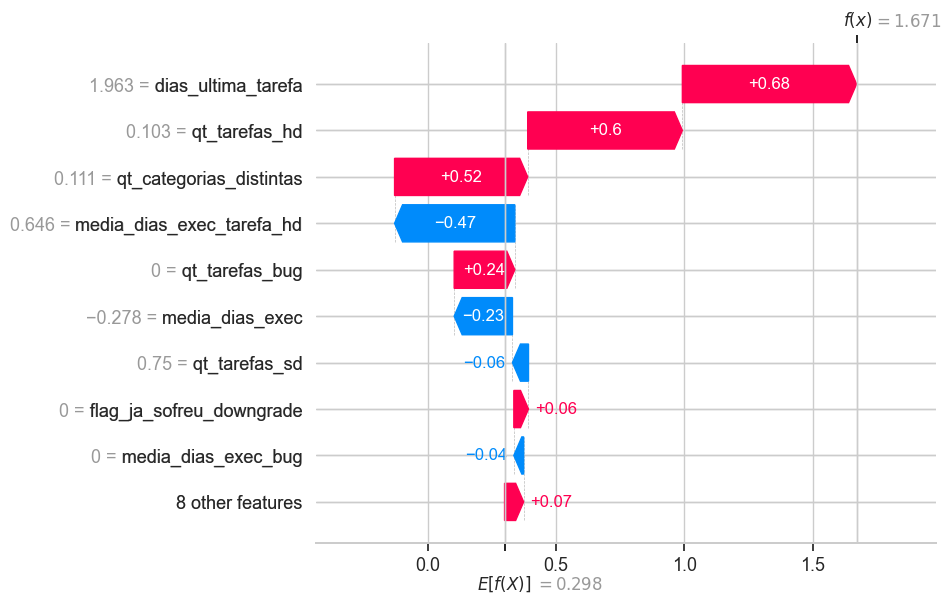

In [60]:
# Inicializa o renderizador de JavaScript para exibir os gráficos no Notebook
shap.initjs()

# Instancia o Explainer otimizado para árvores (XGBoost)
# Passamos o modelo já treinado diretamente
explainer = shap.TreeExplainer(modelo_xgb)

# Calcula os valores SHAP para a base de teste (ou treino se preferir a visão geral)
# É importante passar o DataFrame com as colunas nomeadas para o gráfico ficar legível
# Se o seu X_test estiver escalado e sem colunas, use: pd.DataFrame(X_test_scaled, columns=X.columns)
shap_values = explainer(pd.DataFrame(X_test_scaled, columns=X_test.columns))

# Gráfico 1: Summary Plot (Visão Global Direcional)
print("--- VISÃO GLOBAL DE IMPACTO DAS FEATURES ---")
shap.summary_plot(shap_values, X_test)

# Gráfico 2: Waterfall Plot (Explicação de um cliente específico)
# Vamos pegar o primeiro cliente do set de teste (índice 0) para auditar o porquê do score dele
print("\n--- AUDITORIA INDIVIDUAL: POR QUE ESTE CLIENTE RECEBEU ESSE SCORE? ---")
shap.plots.waterfall(shap_values[0])

# CalibratedClassifierCV

In [65]:
from sklearn.calibration import CalibratedClassifierCV, calibration_curve

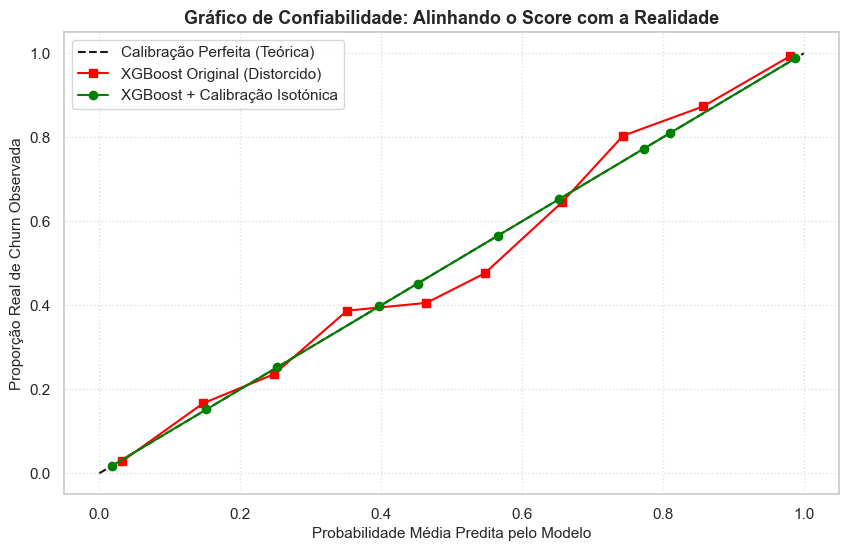

In [66]:
# Instanciar o calibrador usando o modelo XGBoost já configurado
modelo_calibrado = CalibratedClassifierCV(
    estimator=modelo_xgb,
    method='isotonic',
    cv='prefit'
)

# 2. Ajustar o calibrador usando o set de TESTE ou VALIDAÇÃO
modelo_calibrado.fit(X_test, y_test)

# O restante do código de plotagem permanece exatamente o mesmo...
prob_originais = modelo_xgb.predict_proba(X_test)[:, 1]
prob_calibradas = modelo_calibrado.predict_proba(X_test)[:, 1]

# Calcular os pontos para o gráfico de confiabilidade
sub_y_orig, sub_x_orig = calibration_curve(y_test, prob_originais, n_bins=10)
sub_y_calib, sub_x_calib = calibration_curve(y_test, prob_calibradas, n_bins=10)

# Plotar o diagnóstico visual comparativo
plt.figure(figsize=(10, 6))
plt.plot([0, 1], [0, 1], "k--", label="Calibração Perfeita (Teórica)")
plt.plot(sub_x_orig, sub_y_orig,   "s-", color="red",   label="XGBoost Original (Distorcido)")
plt.plot(sub_x_calib, sub_y_calib, "o-", color="green", label="XGBoost + Calibração Isotónica")

plt.xlabel("Probabilidade Média Predita pelo Modelo", fontsize=11)
plt.ylabel("Proporção Real de Churn Observada", fontsize=11)
plt.title("Gráfico de Confiabilidade: Alinhando o Score com a Realidade", fontsize=13, fontweight='bold')
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc="upper left")
plt.show()

In [68]:
# A Curva Vermelha: O XGBoost Original (Distorcido)
# Repare que o XGBoost original faz uma curva clássica em formato de "S"
# invertido (ou de onda) em relação à linha pontilhada preta (que é a calibração perfeita).

# O Diagnóstico: O modelo original estava subestimando o risco em algumas
# faixas e superestimando agressivamente nos extremos.

# Quando o modelo original marcava um cliente com uma probabilidade de churn de,
# por exemplo, 0.4 (40%), a proporção real de clientes daquela faixa que cancelavam de verdade estava perto de 0.1 (10%).

# O perigo comercial: Se você entregasse o modelo original para o time de CS,
# eles abririam chamados desesperados para clientes com 40% ou 50% de score que,
# na realidade do banco de dados, eram contas muito mais estáveis.
# O modelo era alarmista demais no meio da curva.

# 2. A Curva Verde: O XGBoost + Calibração Isotônica
# Olhe para a linha verde agora. A Regressão Isotônica foi simplesmente cirúrgica.
# Ela puxou os outputs distorcidos do XGBoost e colou a curva verde quase perfeitamente
# em cima da diagonal teórica de 45 graus.

# O significado prático: Agora, a probabilidade virou matemática real e linear.
# Se o seu modelo calibrado disser que um cliente tem 20% de risco, significa que a
# chance real dele dar churn é de exatamente 20%. Se disser que é 60%, o risco triplicou de fato.

# Ganho para o Negócio: Você acabou de dar ao time de CS uma métrica confiável para priorização
# financeira. O score de 0 a 100% agora pode virar gatilho de saúde financeira real no relatório final.

# Salva Modelo Calibrado

In [69]:
joblib.dump(modelo_calibrado, 'src/modelo_xgb_calibrado.pkl')

['src/modelo_xgb_calibrado.pkl']

# Compara Métricas

In [70]:
precisao_reglog = precision_score(y_test, y_pred_reglog)
precisao_rf     = precision_score(y_test, y_pred_rf)
precisao_xgb    = precision_score(y_test, y_pred_xgb)

recall_reglog   = recall_score(y_test, y_pred_reglog)
recall_rf       = recall_score(y_test, y_pred_rf)
recall_xgb      = recall_score(y_test, y_pred_xgb)

acuracia_reglog = accuracy_score(y_test, y_pred_reglog)
acuracia_rf     = accuracy_score(y_test, y_pred_rf)
acuracia_xgb    = accuracy_score(y_test, y_pred_xgb)

f1_score_reglog = f1_score(y_test, y_pred_reglog)
f1_score_rf     = f1_score(y_test, y_pred_rf)
f1_score_xgb    = f1_score(y_test, y_pred_xgb)

roc_auc_reglog  = roc_auc_score(y_test, y_probs_reglog)
roc_auc_rf      = roc_auc_score(y_test, y_probs_rf)
roc_auc_xgb     = roc_auc_score(y_test, y_probs_xgb)

In [71]:
# Estruturando os dados
dados_metricas = {
    "Modelo": [
        "Regressão Logística",
        "Random Forest",
        "XGBoost",
    ]
    * 5,
    "Métrica": (
        ["Precisão"]    * 3
        + ["Recall"]    * 3
        + ["Acurácia"]  * 3
        + ["F1-Score"]  * 3
        + ["ROC AUC"]   * 3
    ),
    "Valor": [
        precisao_reglog,
        precisao_rf,
        precisao_xgb,
        recall_reglog,
        recall_rf,
        recall_xgb,
        acuracia_reglog,
        acuracia_rf,
        acuracia_xgb,
        f1_score_reglog,
        f1_score_rf,
        f1_score_xgb,
        roc_auc_reglog,
        roc_auc_rf,
        roc_auc_xgb
    ]
}

df_metrics = pd.DataFrame(dados_metricas)
df_metrics

,Modelo,Métrica,Valor
0,Regressão Logística,Precisão,0.751553
1,Random Forest,Precisão,0.792069
2,XGBoost,Precisão,0.846618
3,Regressão Logística,Recall,0.898515
4,Random Forest,Recall,0.914604
5,XGBoost,Recall,0.867574
6,Regressão Logística,Acurácia,0.771793
7,Random Forest,Acurácia,0.813607
8,XGBoost,Acurácia,0.834160
9,Regressão Logística,F1-Score,0.818489


## Plot

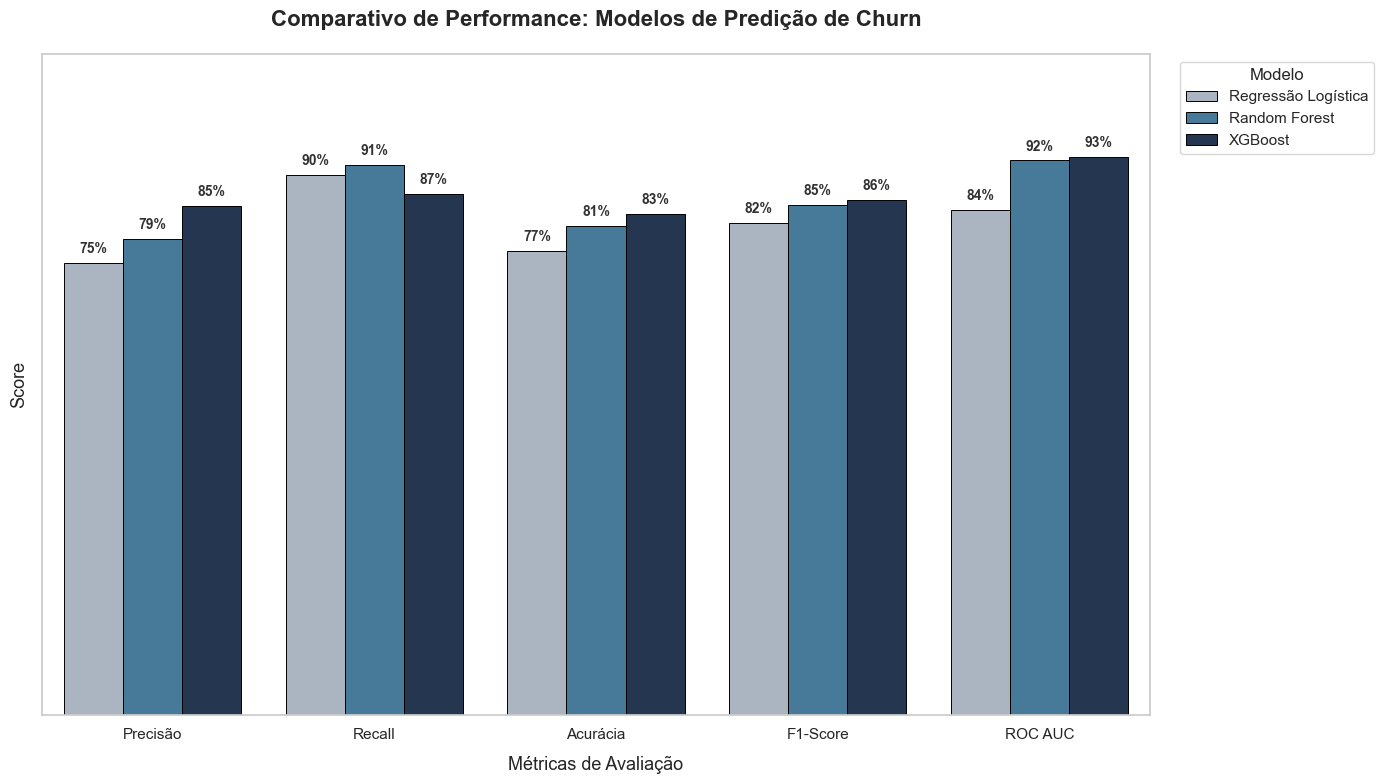

In [72]:
# Configurando o visual do gráfico
plt.figure(figsize=(14, 8))
sns.set_theme(style="whitegrid")

# Paleta de cores sênior e profissional
cores = ["#a6b5c5", "#3a7ca5", "#1d3557"]

# Criando o gráfico de barras agrupadas por Métrica
ax = sns.barplot(
    data=df_metrics,
    x="Métrica",
    y="Valor",
    hue="Modelo",
    palette=cores,
    edgecolor="black",
    linewidth=0.7,
)

# Perfumaria Executiva (Títulos e Legendas)
plt.title(
    "Comparativo de Performance: Modelos de Predição de Churn",
    fontsize=16,
    fontweight="bold",
    pad=20,
)
plt.xlabel("Métricas de Avaliação", fontsize=13, labelpad=10)
plt.ylabel("Score", fontsize=13, labelpad=10)
plt.ylim(0, 1.1)  # Dá um respiro no topo para os rótulos de texto

# ─── ALTERAÇÃO AQUI: Remove os números do eixo Y, mas mantém a palavra "Score" ───
plt.yticks([], [])

# Move a legenda para fora/canto para não atrapalhar as barras
plt.legend(
    title="Modelo",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    fontsize=11,
    title_fontsize=12,
)

# Adicionando os valores exatos em cima de cada barra automaticamente
for p in ax.patches:
    if (
        p.get_height() > 0
    ):  # Garante que só vai plotar se a barra tiver altura
        ax.annotate(
            f"{p.get_height() * 100:.0f}%",  # Mostra em formato de porcentagem limpa (ex: 95%)
            (p.get_x() + p.get_width() / 2.0, p.get_height()),
            ha="center",
            va="center",
            xytext=(0, 10),
            textcoords="offset points",
            fontsize=10,
            fontweight="bold",
            color="#333333",
        )

plt.tight_layout()
plt.show()

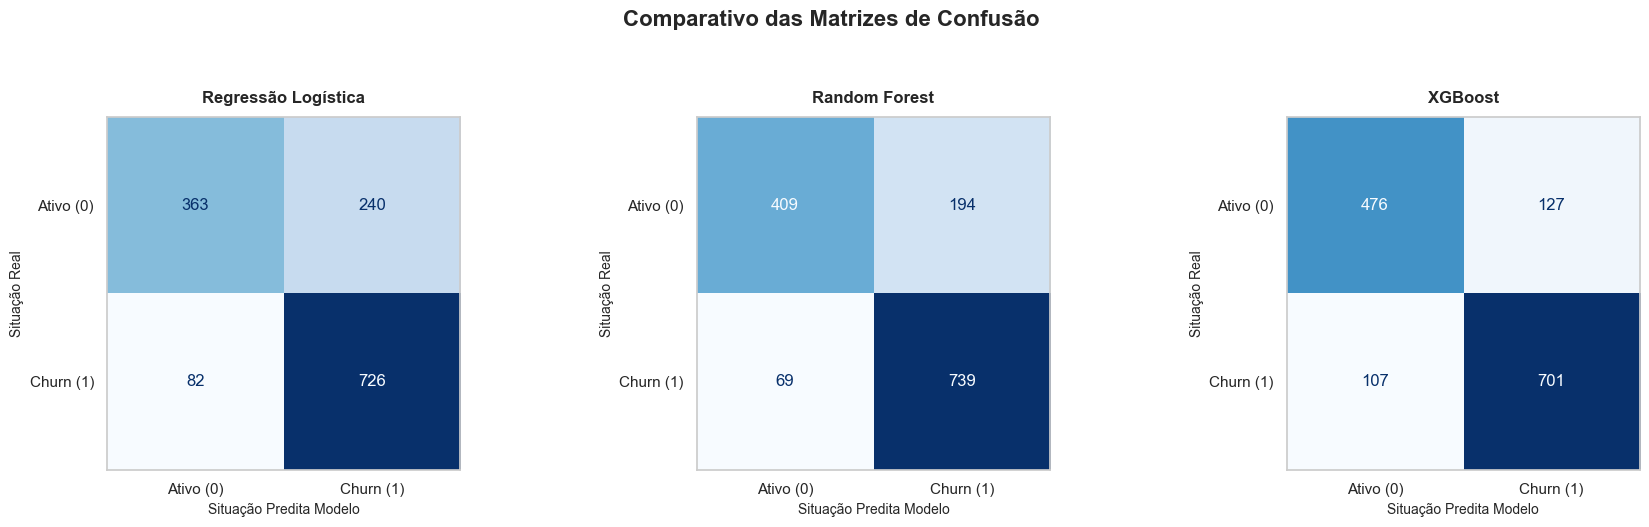

In [73]:
# Criar a figura com 1 linha e 3 colunas
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Comparativo das Matrizes de Confusão', fontsize=16, fontweight='bold', y=1.05)

# Lista de configurações para iterar no loop
modelos = [
    {"cm": cm_reglog,  "title":  "Regressão Logística", "ax": axes[0]},
    {"cm": cm_rf,       "title": "Random Forest",       "ax": axes[1]},
    {"cm": cm_xgb,      "title": "XGBoost",             "ax": axes[2]}
]

# Plotar cada matriz no seu respectivo 'ax'
for mod in modelos:
    mod["ax"].grid(False)  # Remove linhas de grade que desalinhame a matriz

    disp = ConfusionMatrixDisplay(confusion_matrix=mod["cm"], display_labels=['Ativo (0)', 'Churn (1)'])

    # O segredo está em passar o 'ax' correto para o plot
    disp.plot(cmap='Blues', values_format='d', colorbar=False, ax=mod["ax"])

    # Customizações por sub-plot
    mod["ax"].set_title(mod["title"], fontsize=12, fontweight='bold', pad=10)
    mod["ax"].set_ylabel('Situação Real', fontsize=10)
    mod["ax"].set_xlabel('Situação Predita Modelo', fontsize=10)

# Ajusta o espaçamento para não sobrepor os textos
plt.tight_layout()
plt.show()